In [74]:
%load_ext autoreload
%autoreload 2
import importlib 
hg = importlib.import_module(".model", "src")

m = importlib.import_module(".analytic-intersection-asymptotics", "src")
from matplotlib import pyplot as plt
import numpy as np
from scipy.special import binom
import xgi
import copy 
plt.style.use("seaborn-whitegrid")

from collections import defaultdict, Counter
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap, ListedColormap

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


/tmp/ipykernel_2777489/1788881870.py:12: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use("seaborn-whitegrid")


### Parameters

In [75]:
k_max = 15
pars = {
    "eta"   : 0.3, 
    "beta"  : np.zeros(k_max),
    "gamma" : np.zeros(k_max)
}

pars["beta"][0:5] = 1/5
pars["gamma"][0:5] = 1/5

eta, beta, gamma = pars["eta"], pars["beta"], pars["gamma"]

### Build some simple simulations for comparison

In [76]:
timesteps = int(1e5)
H = hg.GrowingHypergraph()
H.add_edge((0, 1))
H.add_edge((2, 3))

max_size = 3
# r = np.zeros(shape=(max_size, max_size, max_size))
r = defaultdict(int)
r[(2, 2, 0)] = 1
save_r = []
edge_size_dict = defaultdict(int)
edge_size_dict[2] += 2


In [77]:
for cc in range(timesteps): 
    H.sample_edge(eta, beta, gamma, True)

In [78]:
def intersection_profile(H, update_every = 1):

    timesteps = len(H.edges)
    r = defaultdict(int)
    # r[(2, 2, 0)] = 1
    save_r = []
    edge_size_dict = defaultdict(int)
    # edge_size_dict[2] += 2

    R = np.zeros(shape = (timesteps // update_every + 1, k_max), dtype = int)

    for eid in H.edges:
        e = H.edges.members(eid)
        e_size = len(e)
        de = H.edge_neighborhood(eid, prior_only = True, as_node_sets = True)
        # print(len(de))
        # print(eid, e)
        for nb in de:
            nb_size = len(nb)
            k = len(e.intersection(nb))
            r[(e_size, nb_size, k)] += 1
            # if nb_size != e_size:
            #     r[(nb_size, e_size, k)] += 1
                
        neighbor_sizes = [len(x) for x in de]
        nb_size_cnt = Counter(neighbor_sizes)
        for j, nj in edge_size_dict.items():
            # assert(nj >= nb_size_cnt[j])
            r[(j, e_size, 0)] += nj - nb_size_cnt[j]
            # if j != e_size:
            #     r[(e_size, j, 0)] += nj - nb_size_cnt[j]
        
        # print(eid, update_every)
        if eid % update_every == 0:
        # print(cc)
            for k in range(k_max):
                R[eid//update_every, k] = sum([r[(i, j, k)] for i in range(k_max) for j in range(k_max)])
        edge_size_dict[e_size] += 1
    R = R / R.sum(axis = 1)[:, None] 
        
    return r, R
        

In [79]:
def approximation(k_max, pars):
    MC = m.MatrixConstructor(k_max, pars)
    M = MC.matrix_of_linear_map()
    EV = np.linalg.eig(M)
    print(f"Leading eigenvalue = {np.abs(EV[0][0]):.3f}")
    v = np.abs(EV[1][:, np.argmax(EV[0])])
    T = m.vec_to_tensor(v, k_max)
    
    return M, T

In [80]:
r, R = intersection_profile(H)

/tmp/ipykernel_2777489/180233017.py:39: RuntimeWarning: invalid value encountered in divide
  R = R / R.sum(axis = 1)[:, None]


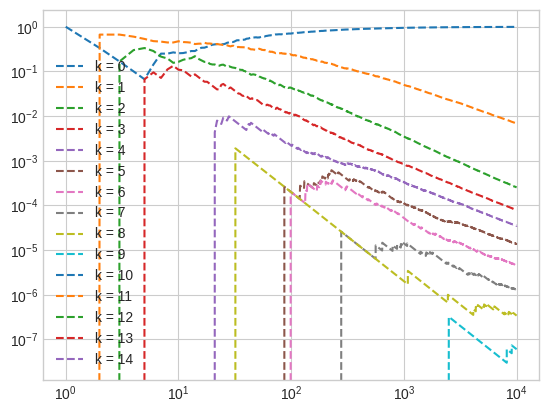

In [81]:
fig, ax = plt.subplots(1, 1)
# R = R / R.sum(axis = 1)[:, None]
for k in range(k_max): 
    ax.plot(R[:, k], label = f"k = {k}", linestyle = "--")

ax.loglog()
ax.legend()

### Linear Algebra Approximation

/home/pchodrow/HyperGraph/code/src/analytic-intersection-asymptotics.py:62: RuntimeWarning: invalid value encountered in divide
  S2_kyljh = binom(H, K)*binom(L - H, Y - K)/binom(L, Y)


Leading eigenvalue = 0.827


[Text(0.5, 1.0, 'Sparsity: 0.990')]

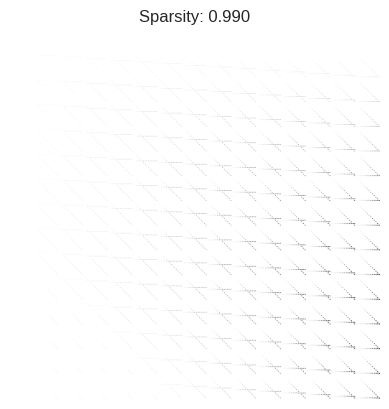

In [82]:
M, T = approximation(k_max, pars)
plt.imshow(M > 0, vmin = 0, vmax = 1)
plt.gca().axis("off")
plt.gca().set(title = f"Sparsity: {(M == 0).mean():.3f}")

# Sample Asymptotics Plot

Eventually we want these curves to line up with the asymptotic lines, although obviously we are not there yet. 

In [83]:

T = T / T[:,:,0].sum()   

q = T.sum(axis = (0, 1))

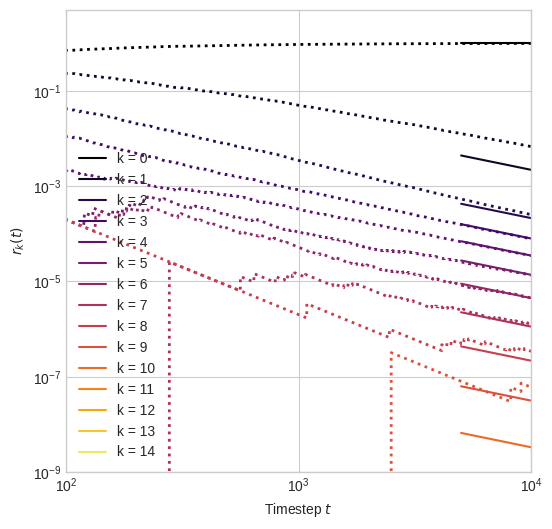

In [87]:
import matplotlib.cm as cm
cmap = cm.inferno

k_min = 0
show_k_up_to = 15

fig, ax = plt.subplots(1, 1, figsize = (6, 6))
R = R / R.sum(axis = 1)[:, None]
for k in range(k_min, show_k_up_to): 
    ax.plot(R[:, k], linestyle = ":", color = cmap(k/show_k_up_to), linewidth = 2)
    # ax.scatter(np.arange(timesteps // update_every)*(update_every), R[:, k],  color = cmap(k/show_k_up_to), facecolors = "none", s = 1)

# T = T / T[:,:,0].sum()   
# q = T.sum(axis = (0, 1))
# q = q / q.sum()
# np.log(q)

m_ = np.arange(50, 1000)*100 + 1

for k in range(k_min, show_k_up_to): 
    if k == 0: 
        ax.plot(q[k]*m_, np.ones_like(m_), label = f"k = {k}", color = cmap(k/show_k_up_to))
    else:    
        ax.plot(m_, q[k]*1/m_, label = f"k = {k}", color = cmap(k/show_k_up_to))

ax.loglog()
plt.legend()
ax.set(xlim = (100, timesteps), ylim = (1e-9, 5), xlabel = r"Timestep $t$", ylabel = r"$r_{k}(t)$")

plt.savefig("figures/intersection-asymptotics.png", dpi = 300, bbox_inches = "tight")



In [32]:
# fig, ax = plt.subplots(1, 1, figsize = (6, 6))
# R = R / R.sum(axis = 1)[:, None]
# for k in range(k_min, show_k_up_to): 
#     ax.plot(R[:, k], linestyle = ":", color = cmap(k/show_k_up_to), linewidth = 2, label = f"k = {k}")
    
# ax.loglog()
# plt.legend()
# ax.set(xlim = (100, timesteps), ylim = (1e-7, 5), xlabel = r"Timestep $t$", ylabel = r"$r_{k}(t)$")

# plt.savefig("../fig/talk/intersection-asymptotics-no-theory.png", dpi = 300, bbox_inches = "tight")


In [33]:
T_empirical = np.array([[[r[(i, j, k)] for k in range(k_max)] for j in range(k_max)] for i in range(k_max)])
T_empirical = T_empirical / T_empirical.sum()

In [34]:
# empirical conditional probabilities
P_empirical = T_empirical.copy()

P_ij_empirical = P_empirical.sum(axis = 2)

P_empirical = P_empirical / P_ij_empirical[:, :, None]
# # P[denom == 0] = 0

# # expectations
R_empirical = (P_empirical*np.arange(0, P_empirical.shape[2])[None, None, :])
R_empirical[np.isnan(R_empirical)] = 0
R_empirical = R_empirical.sum(axis = 2)

/tmp/ipykernel_2777489/3619764538.py:6: RuntimeWarning: invalid value encountered in divide
  P_empirical = P_empirical / P_ij_empirical[:, :, None]


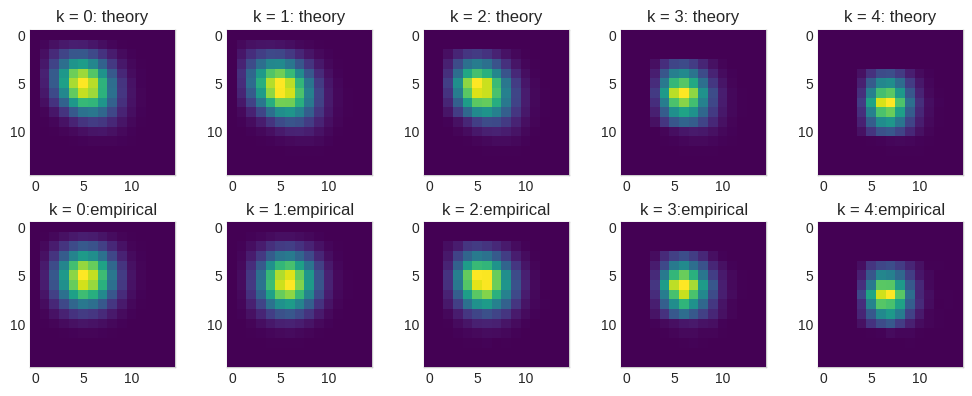

In [35]:
# slices of T line up pretty well with the empirical values, but the scales are off...

fig, ax = plt.subplots(2, 5, figsize = (10, 4))

for k in range(5):
    
    
    ax[ 0, k].imshow(T[:,:,k], cmap = "viridis", zorder = 10)
        
    ax[ 0, k].set(title = f"k = {k}: theory")
    
    if k >= 1:
        to_plot = T_empirical[:,:,k]*timesteps
    else:
        to_plot = T_empirical[:,:,k]

    ax[ 1, k].imshow(to_plot, cmap = "viridis", zorder = 10)
    ax[ 1, k].set(title = f"k = {k}:empirical")
    
plt.tight_layout()

In [36]:
# computation of conditionally expected intersection sizes

P_theory = T.copy() 
P_theory[1:,1:,1:] = P_theory[1:,1:,1:] / timesteps
P_theory = P_theory / P_theory.sum() 

# conditional probability of intersection size k given edge sizes i, j
P_theory_conditioned = P_theory / P_theory.sum(axis = 2)[:,:,None]

# form conditional expectation
E_theory = np.zeros(shape = (k_max, k_max))
for k in range(k_max):
    E_theory += P_theory[:,:,k]*k
    

# conditional probability of intersection size k given edge sizes i, j
P_empirical = T_empirical / T_empirical.sum()
P_empirical_conditioned = P_empirical / P_empirical.sum(axis = 2)[:,:,None]
E_empirical = np.zeros(shape = (k_max, k_max))

for k in range(k_max):
    E_empirical += P_empirical[:,:,k]*k

/tmp/ipykernel_2777489/3833274597.py:8: RuntimeWarning: invalid value encountered in divide
  P_theory_conditioned = P_theory / P_theory.sum(axis = 2)[:,:,None]
/tmp/ipykernel_2777489/3833274597.py:18: RuntimeWarning: invalid value encountered in divide
  P_empirical_conditioned = P_empirical / P_empirical.sum(axis = 2)[:,:,None]


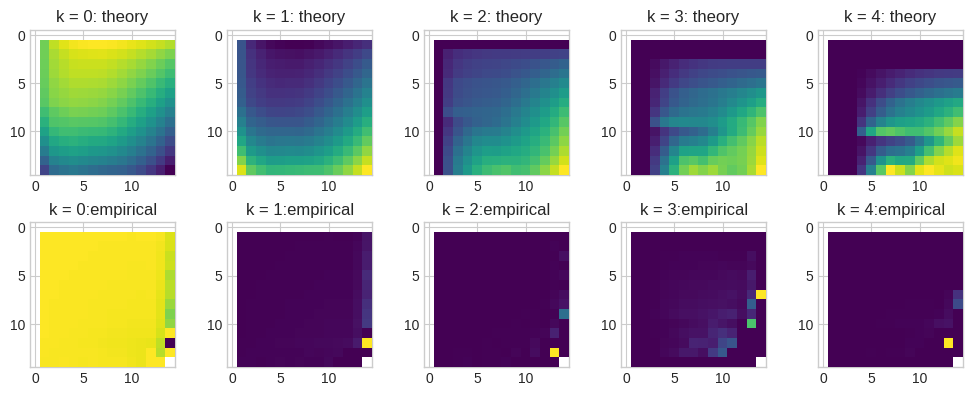

In [37]:
fig, ax = plt.subplots(2, 5, figsize = (10, 4))

for k in range(5):
    
    ax[ 0, k].imshow(P_theory_conditioned[:,:,k], cmap = "viridis", zorder = 10, )
        
    ax[ 0, k].set(title = f"k = {k}: theory")
    
    if k >= 1:
        to_plot = P_empirical_conditioned[:,:,k]
    else:
        to_plot = P_empirical_conditioned[:,:,k]

    ax[ 1, k].imshow(to_plot, cmap = "viridis", zorder = 10, )
    ax[ 1, k].set(title = f"k = {k}:empirical")
    
plt.tight_layout()

[Text(0.5, 1.0, 'Theory, mean = 0.00')]

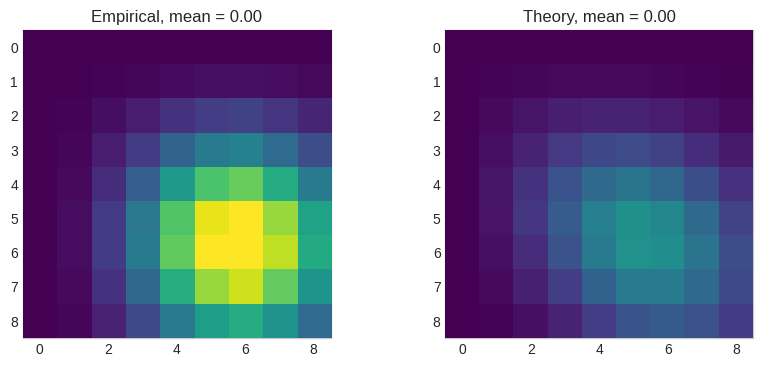

In [38]:
fig, ax = plt.subplots(1, 2, figsize = (10, 4))
ax[0].imshow(E_empirical[:9, :9], vmin = 0, vmax = .00003, cmap = "viridis", zorder = 10)
ax[0].set(title = f"Empirical, mean = {np.nanmean(E_empirical):.2f}")
ax[1].imshow(E_theory[:9, :9], vmin = 0, vmax = .00003,cmap = "viridis", zorder = 10)
ax[1].set(title = f"Theory, mean = {np.nanmean(E_theory):.2f}")

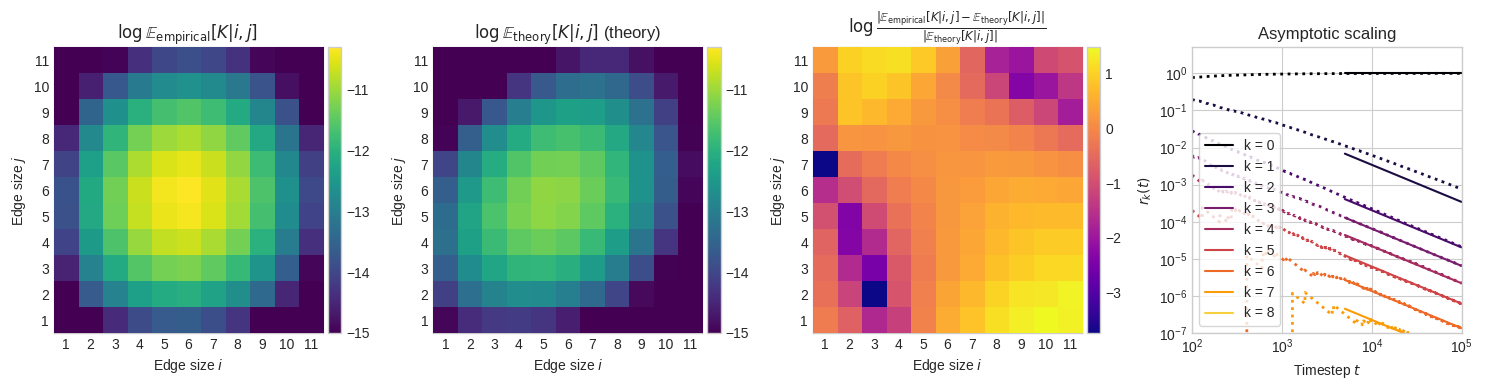

In [39]:
from mpl_toolkits.axes_grid1 import make_axes_locatable


# figure for paper: four panels, one showing slope, one showing actual expected intersection sizes in graph, one showing theory, and one showing relative errors. 

# this is pretty good but we need to do some work with the legends and colorbars. 

k_min = 0
show_k_up_to = 12
show_k_up_to_on_asymptotics = 9
import matplotlib.cm as cm
cmap = cm.inferno

# fig, axarr = plt.subplots(2, 2, figsize = (7, 7))

fig, axarr = plt.subplots(1, 4, figsize = (15, 4))





# 1. plot slopes
ax = axarr.ravel()[3]
R_ = R / R.sum(axis = 1)[:, None]
for k in range(k_min, show_k_up_to): 
    ax.plot(R_[    :, k], linestyle = ":", color = cmap(k/show_k_up_to_on_asymptotics), linewidth = 2)

m_ = np.arange(50, 1000)*100 + 1

for k in range(k_min, show_k_up_to_on_asymptotics): 
    if k == 0: 
        ax.plot(q[k]*m_, np.ones_like(m_), label = f"k = {k}", color = cmap(k/show_k_up_to_on_asymptotics))
    else:    
        ax.plot(m_, q[k]*1/m_, label = f"k = {k}", color = cmap(k/show_k_up_to_on_asymptotics))

ax.loglog()


ax.legend(frameon=True)

ax.set(xlim = (100, timesteps), ylim = (1e-7, 5), xlabel = r"Timestep $t$", ylabel = r"$r_{k}(t)$", title = "Asymptotic scaling")


vmax = np.log(max(E_empirical.max(), E_theory.max()))
vmin = -15

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)

cax.axis("off")


# 2. plot empirical conditional intersection sizes
ax = axarr.ravel()[0]
im = ax.imshow(np.log(E_empirical[1:show_k_up_to,1:show_k_up_to]), cmap = "viridis", vmin = vmin, vmax = vmax, zorder = 100, aspect = "auto", origin = "lower")
ax.set(title = r"$\log \mathbb{E}_{\mathrm{empirical}}[K | i,j]$ ", xlabel = r"Edge size $i$", ylabel = r"Edge size $j$")

ticks = range(0, show_k_up_to-1)
tick_labels = range(1, show_k_up_to)
ax.set_xticks(ticks)
ax.set_xticklabels(tick_labels)
ax.set_yticks(ticks)
ax.set_yticklabels(tick_labels)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
   
plt.colorbar(im, cax=cax)

# plt.colorbar(im, cax = axarr[0, 1])

# fig.colorbar(im, cax=cbar_ax)




# 3. theoretical expectations
# do these need to be scaled by m in some way?

ax = axarr.ravel()[1]
im = ax.imshow(np.log(E_theory[1:show_k_up_to,1:show_k_up_to]), cmap = "viridis", vmin = vmin, vmax = vmax, zorder = 100, aspect = "auto", origin = "lower")
ax.set(title = "$\log \mathbb{E}_{\mathrm{theory}}[K | i,j]$ (theory)", xlabel = r"Edge size $i$", ylabel = r"Edge size $j$")
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
   
plt.colorbar(im, cax=cax)

ax.set_xticks(ticks)
ax.set_xticklabels(tick_labels)
ax.set_yticks(ticks)
ax.set_yticklabels(tick_labels)

# 4. relative errors

err = np.log(np.abs(E_theory[1:show_k_up_to,1:show_k_up_to] - E_empirical[1:show_k_up_to,1:show_k_up_to]) / E_theory[1:show_k_up_to,1:show_k_up_to])
ax = axarr.ravel()[2]
im = ax.imshow(err[:show_k_up_to,:show_k_up_to], cmap = "plasma", zorder = 100, aspect = "auto", origin = "lower")

ax.set(title = r"$\log \frac{|\mathbb{E}_\mathrm{empirical}[K | i,j] - \mathbb{E}_{\mathrm{theory}}[K | i,j]|}{|\mathbb{E}_\mathrm{theory}[K | i,j]|}$", xlabel = r"Edge size $i$", ylabel = r"Edge size $j$")

ax.set_xticks(ticks)
ax.set_xticklabels(tick_labels)
ax.set_yticks(ticks)
ax.set_yticklabels(tick_labels)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)



plt.colorbar(im, cax=cax)




# this plot needs a separate colorbar

plt.tight_layout()

plt.savefig("../fig/intersection-asymptotics-4-panel.png", dpi = 300, bbox_inches = "tight")

## Fun Viz of Matrix Sparsity

This would be a nice candidate for making an art piece to commemorate the project! 

/tmp/ipykernel_2777489/3185829134.py:16: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(M[k_max*(k_max+1):,k_max*(k_max+1):]), interpolation="none", cmap = "twilight")


(-0.5, 43.5, 43.5, -0.5)

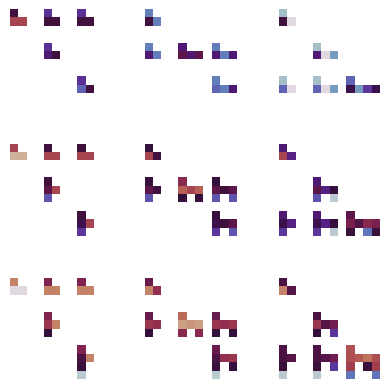

In [40]:
k_max = 4
pars = {
    "eta"   : 0.4, 
    "beta"  : np.zeros(k_max),
    "gamma" : np.zeros(k_max)
}

pars["beta"][0:5] = 1/5
pars["gamma"][0:5] = 1/5

eta, beta, gamma = pars["eta"], pars["beta"], pars["gamma"]


MC = m.MatrixConstructor(k_max, pars)
M = MC.matrix_of_linear_map()
plt.imshow(np.log(M[k_max*(k_max+1):,k_max*(k_max+1):]), interpolation="none", cmap = "twilight")
plt.gca().axis("off")
